In [90]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors



In [91]:
d_20250529 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/data/triples_CO_sbert/goose_20250529.export_triples_sbert.csv')
d_20250530 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/data/triples_CO_sbert/goose_20250530.export_triples_sbert.csv')
d_20250531 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/data/triples_CO_sbert/goose_20250531.export_triples_sbert.csv')
d_20250601 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/data/triples_CO_sbert/goose_20250601.export_triples_sbert.csv')
d_20250602 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/data/triples_CO_sbert/goose_20250602.export_triples_sbert.csv')
d_20250603 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/data/triples_CO_sbert/goose_20250603.export_triples_sbert.csv')
d_20250604 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/data/triples_CO_sbert/goose_20250604.export_triples_sbert.csv')
d_20250605 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/data/triples_CO_sbert/goose_20250605.export_triples_sbert.csv')

In [92]:
def embed(df_copy):

    df = df_copy.copy(deep=True) 

    s = df['embedding_json'].str.lstrip('[')
    s = s.str.rstrip(']')
    s = s.str.split(',')
    s = s.apply(np.array)
    df['embedding_json'] = s
    x = np.vstack(df['embedding_json'])
    x2d = TSNE(n_components=2).fit_transform(x)
    newdf = pd.DataFrame({
    'x': x2d[:,0],
    'y': x2d[:,1],
    'sbert_text': df['sbert_text'].to_numpy(),
    'GlobalEventID': df['GlobalEventID'].to_numpy(),
        })
    return newdf


In [93]:
e_20250529 = embed(d_20250529)
e_20250530 = embed(d_20250530)
e_20250531 = embed(d_20250531)
e_20250601 = embed(d_20250601)
e_20250602 = embed(d_20250602)
e_20250603 = embed(d_20250603)
e_20250604 = embed(d_20250604)
e_20250605 = embed(d_20250605)

In [94]:
x2d = pd.concat([e_20250529,e_20250530,e_20250531,e_20250601,e_20250602,e_20250603,e_20250604,e_20250605],ignore_index=True)

In [98]:
fig = px.scatter(e_20250602,
                     x="x",
                     y="y",
                     hover_data=['sbert_text','GlobalEventID'], # Display this on hover
                     title="20250602 CO")

In [99]:
fig.show()

In [100]:
d_20140521 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/data/triples_CA_sbert/goose_20140521.export_triples_sbert.csv')
d_20140522 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/data/triples_CA_sbert/goose_20140522.export_triples_sbert.csv')
d_20140523 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/data/triples_CA_sbert/goose_20140523.export_triples_sbert.csv')
d_20140524 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/data/triples_CA_sbert/goose_20140524.export_triples_sbert.csv')
d_20140525 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/data/triples_CA_sbert/goose_20140525.export_triples_sbert.csv')
d_20140526 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/data/triples_CA_sbert/goose_20140526.export_triples_sbert.csv')
d_20140527 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/data/triples_CA_sbert/goose_20140527.export_triples_sbert.csv')
d_20140528 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/data/triples_CA_sbert/goose_20140528.export_triples_sbert.csv')

In [101]:
e_20140521 = embed(d_20140521)
e_20140522 = embed(d_20140522)
e_20140523 = embed(d_20140523)
e_20140524 = embed(d_20140524)
e_20140525 = embed(d_20140525)
e_20140526 = embed(d_20140526)
e_20140527 = embed(d_20140527)
e_20140528 = embed(d_20140528)

In [104]:
CA_x2d = pd.concat([e_20140521,e_20140522,e_20140523,e_20140524,e_20140525,e_20140526,e_20140527,e_20140528],ignore_index=True)

In [105]:
fig = px.scatter(CA_x2d,
                     x="x",
                     y="y",
                     hover_data=['sbert_text','GlobalEventID'], # Display this on hover
                     title="2014 CA")
fig.show()

clusters: 31, noise points: 205


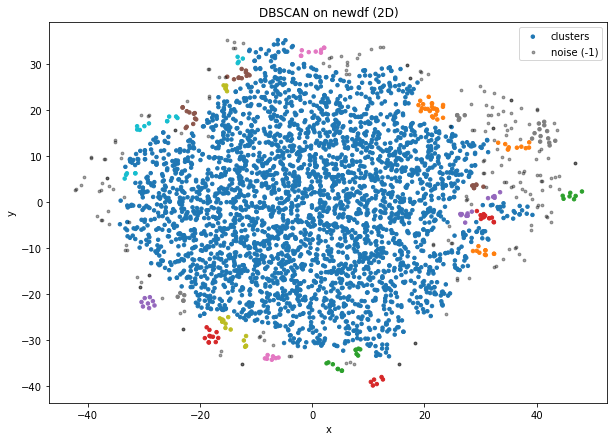

In [ ]:
# 1) Get the 2-D coordinates
X = CA_x2d[['x', 'y']].to_numpy(dtype=float)

# 2) (Optional but common) scale so eps is in a sane range
X_scaled = StandardScaler().fit_transform(X)

# 3) Fit DBSCAN (tune eps/min_samples!)
db = DBSCAN(eps=0.1, min_samples=5)  # start here; adjust below
labels = db.fit_predict(X_scaled)     # -1 = noise

# 4) Attach results
CA_x2d['cluster'] = labels

# 5) Quick summary
n_noise = (labels == -1).sum()
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"clusters: {n_clusters}, noise points: {n_noise}")

# 6) Visualize
noise = CA_x2d['cluster'] == -1
plt.figure(figsize=(10,7))
plt.scatter(CA_x2d.loc[~noise, 'x'], CA_x2d.loc[~noise, 'y'],
            c=CA_x2d.loc[~noise, 'cluster'], s=12, cmap='tab10', label='clusters')
plt.scatter(CA_x2d.loc[noise, 'x'], CA_x2d.loc[noise, 'y'],
            s=8, alpha=0.35, c='k', label='noise (-1)')
plt.legend(); plt.title('DBSCAN on newdf (2D)'); plt.xlabel('x'); plt.ylabel('y')
plt.show()

In [80]:
CA_x2d

,x,y,sbert_text,GlobalEventID,cluster
0,15.662479,9.335284,$ 500 month is in rent,298182819,0
1,14.222776,-1.383981,% are in three Arizona counties,298224590,1
2,-18.729330,-20.555485,* were convinced,298231728,2
3,2.273388,-14.035872,10 Freeway was shut down in directions,298120499,-1
4,-26.292347,13.281597,120 years is in prison,298231070,-1
...,...,...,...,...,...
3742,25.850271,18.881779,year old man fatally shot woman According Asso...,299136348,-1
3743,-5.619608,26.933010,year ’s Midwest drought has given way to wette...,299119937,29
3744,-1.691746,-13.608823,you are confined without human contact,299121278,4
3745,-15.935414,12.839334,your facilities real estate,299119937,25


In [88]:
fig = px.scatter(CA_x2d,
                     x="x",
                     y="y",
                     color="cluster",
                     hover_data=['sbert_text','GlobalEventID'], # Display this on hover
                     title="2014 CA")

In [89]:
fig.show()

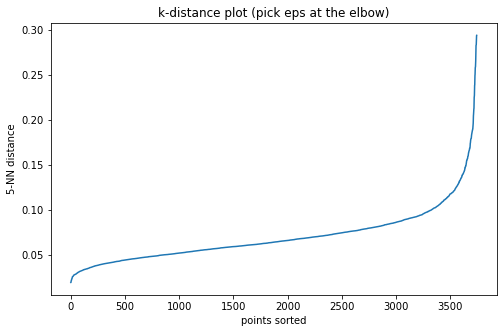

In [77]:
k = 5  # try the same as min_samples
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dists = np.sort(distances[:, -1])
plt.figure(figsize=(8,5))
plt.plot(k_dists)
plt.ylabel(f'{k}-NN distance'); plt.xlabel('points sorted')
plt.title('k-distance plot (pick eps at the elbow)')
plt.show()